# Introduction

We create a refined set of behavioral and value-based features grounded in the EDA and 
statistical findings. These transformations help the models capture nonlinear churn 
patterns and segment-level risks. After preprocessing, several Logistic Regression 
versions are trained and evaluated to determine the strongest churn drivers.

In [1]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modeling
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

sns.set_theme(style="whitegrid")
plt.style.use('seaborn-v0_8')

CHURN_COLOR = "#d62728"
RETAIN_COLOR = "#1f77b4"

def set_plot_style():
    plt.rcParams['figure.figsize'] = (7,5)
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['figure.dpi'] = 120
set_plot_style()

pd.set_option('display.max_columns', None)


In [2]:
import os

CURRENT_DIR = os.getcwd()

if CURRENT_DIR.endswith("Users") or CURRENT_DIR.endswith("koutr"):
    PROJECT_DIR = r"C:\Users\koutr\OneDrive\Υπολογιστής\Bank Churn Project"
    os.chdir(PROJECT_DIR)
    CURRENT_DIR = os.getcwd()

print("Current working directory:", CURRENT_DIR)

PROCESSED_DATA_PATH = os.path.join(
    CURRENT_DIR, "data", "processed", "bank_churn_cleaned_final.csv"
)

df = pd.read_csv(PROCESSED_DATA_PATH)
df.head()

Current working directory: C:\Users\koutr\OneDrive\Υπολογιστής\Bank Churn Project


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,age_capped
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,42
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,42
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,39
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,43


In [3]:
# Fix data types to ensure correct behavior in modeling and statistical analysis

# Convert true binary/numeric variables to int
for col in ['churn', 'active_member', 'credit_card']:
    df[col] = df[col].astype(int)

# Convert nominal variables to categorical for memory efficiency and cleaner encoding
for col in ['country', 'gender']:
    df[col] = df[col].astype('category')

df['products_number'] = df['products_number'].astype(int)

# Quick check
df.dtypes

customer_id            int64
credit_score           int64
country             category
gender              category
age                    int64
tenure                 int64
balance              float64
products_number        int32
credit_card            int32
active_member          int32
estimated_salary     float64
churn                  int32
age_capped             int64
dtype: object

In [4]:
def feature_engineering(df):
    df = df.copy()

    # Age Features 
    df['age_group'] = pd.cut(
        df['age'], bins=[18, 30, 45, 60, 100],
        labels=['18-30', '31-45', '46-60', '60+'],
        include_lowest=True
    )
    df['is_senior'] = (df['age'] >= 60).astype(int)

    # Tenure Features 
    df['tenure_group'] = pd.cut(
        df['tenure'], bins=[0, 2, 6, 10],
        labels=['0-2', '3-6', '7-10'], include_lowest=True
    )
    df['is_new_customer'] = (df['tenure'] < 2).astype(int)

    # Balance / Salary 
    df['balance_to_salary'] = df['balance'] / df['estimated_salary']

    high_balance_threshold = df['balance'].quantile(0.75)
    mid_balance = df['balance'].median()

    df['high_value_customer'] = (df['balance'] > high_balance_threshold).astype(int)

    # Product Features 
    df['products_bucket'] = pd.cut(
        df['products_number'], bins=[0, 1, 2, 10],
        labels=['0-1', '2', '3+'], include_lowest=True
    )
    df['many_products'] = (df['products_number'] >= 3).astype(int)

    # Behavior Interactions 
    df['inactive_high_balance'] = (
        (df['active_member'] == 0) & (df['balance'] > mid_balance)
    ).astype(int)

    df['active_x_age'] = df['age'] * df['active_member']
    df['products_x_active'] = df['products_number'] * df['active_member']

    # Credit Utilization 
    df['credit_utilization'] = df['balance'] / df['credit_score'].replace(0, np.nan)
    df['credit_utilization'] = df['credit_utilization'].fillna(0)

    # Country Encoding 
    df = pd.get_dummies(df, columns=['country'], drop_first=True)

    # Drop weak features
    df = df.drop(columns=['customer_id', 'credit_card'], errors='ignore')

    return df

# Customer Segmentation (Behavioral & Value-Based)

This section performs customer segmentation based on the most important behavioral and value-related indicators identified from the EDA and statistical analysis.

- The segmentation is business-oriented and groups customers into clear, interpretable segments based on:

- Customer Value (balance + number of products)

- Activity (active vs inactive)

- Age Life Stage (age buckets)

- Loyalty (tenure groups)

**Objective**: To identify which segments exhibit higher churn risk and to support decision-making for targeted retention strategies.

In [5]:
# Value Segmentation

# thresholds
high_balance = df['balance'].quantile(0.75)
mid_balance = df['balance'].median()

def value_segment(row):
    if row['balance'] >= high_balance and row['products_number'] >= 2:
        return "Premium"
    if row['balance'] >= mid_balance:
        return "High Value"
    if row['products_number'] > 1:
        return "Mid Value"
    return "Low Value"

df['value_segment'] = df.apply(value_segment, axis=1)

df['value_segment'].value_counts()

High Value    4143
Mid Value     3214
Low Value     1786
Premium        857
Name: value_segment, dtype: int64

In [6]:
# Age–Life Stage Segmentation
df['age_segment'] = pd.cut(
    df['age'],
    bins=[18, 30, 45, 60, 100],
    labels=['Young', 'Established', 'Mature', 'Senior']
)

df['age_segment'].value_counts()

Established    5921
Young          1946
Mature         1647
Senior          464
Name: age_segment, dtype: int64

In [7]:
# Activity Segmentation
df['activity_segment'] = np.where(
    (df['active_member'] == 0) & (df['balance'] > mid_balance),
    'Inactive High Value',
    np.where(df['active_member'] == 1, 'Active', 'Inactive')
)

df['activity_segment'].value_counts()

Active                 5151
Inactive High Value    2456
Inactive               2393
Name: activity_segment, dtype: int64

In [8]:
# Loyalty Segmentation (Tenure)
df['loyalty_segment'] = pd.cut(
    df['tenure'],
    bins=[0, 2, 6, 10],
    labels=['New', 'Growing', 'Loyal']
)

df['loyalty_segment'].value_counts()

Growing    3977
Loyal      3527
New        2083
Name: loyalty_segment, dtype: int64

In [9]:
#
df['customer_segment'] = (
    df['value_segment'] + " | " +
    df['activity_segment'] + " | " +
    df['age_segment'].astype(str)
)

df['customer_segment'].value_counts()

High Value | Inactive High Value | Established    1223
High Value | Active | Established                 1186
Mid Value | Inactive | Established                 990
Mid Value | Active | Established                   948
Low Value | Inactive | Established                 521
Low Value | Active | Established                   509
High Value | Inactive High Value | Mature          395
High Value | Active | Young                        390
High Value | Active | Mature                       378
High Value | Inactive High Value | Young           374
Mid Value | Inactive | Young                       368
Mid Value | Active | Young                         367
Premium | Inactive High Value | Established        277
Premium | Active | Established                     267
Mid Value | Active | Mature                        255
Low Value | Inactive | Mature                      208
Low Value | Active | Mature                        171
Low Value | Active | Young                         156
High Value

# Conclusion

- Largest segments are High Value and Mid Value customers in the Established stage.

- Strong presence of Inactive sub-segments across all value tiers → key churn-risk groups.

- High Value – Inactive groups stand out as top priority for retention.

- Premium segments are small but represent high-value customers.

- Several very small nan segments indicate minor data-quality issues.

In [10]:
# Apply all feature engineering transformations
df_fe = feature_engineering(df)

# One-hot encode remaining categorical variables
# drop_first=True avoids multicollinearity between dummy variables
df_encoded = pd.get_dummies(
    df_fe,
    columns=['age_group', 'tenure_group', 'gender', 'products_bucket'],
    drop_first=True
)

# Split data into features (X) and target variable (y)
X = df_encoded.drop('churn', axis=1)   # predictors
y = df_encoded['churn']               # target label

In [11]:
# Remove raw categorical segments (they should not appear in the model)
to_drop_vif = [
    'value_segment',
    'age_segment',
    'activity_segment',
    'loyalty_segment',
    'customer_segment'
]

df_encoded = df_encoded.drop(columns=to_drop_vif, errors='ignore')

X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']


In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(df):
    # Convert all columns to float to avoid dtype issues in VIF calculation
    X = df.astype(float).copy()
    
    # Identify constant features (zero variance), which can break VIF computation
    constant_cols = [c for c in X.columns if X[c].var() == 0]
    
    # Remove constant columns before calculating VIF
    X = X.drop(columns=constant_cols, errors='ignore')

    # Compute VIF for each feature to assess multicollinearity
    vif = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })

    return vif.sort_values("VIF", ascending=False)

# Calculate VIF values for the feature matrix
vif_data = compute_vif(X)
vif_data

C:\Users\koutr\New folder\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
26,products_bucket_3+,inf
12,many_products,inf
7,age_capped,3.955688e+04
1,age,3.928897e+04
4,products_number,2.747843e+02
3,balance,8.586817e+01
0,credit_score,8.145322e+01
16,credit_utilization,8.001806e+01
25,products_bucket_2,5.240717e+01
5,active_member,5.108173e+01


In [13]:
drop_for_collinearity = [
    'age', 'is_senior', 'tenure', 'balance',
    'high_value_customer', 'products_number'
]

df_encoded = df_encoded.drop(columns=drop_for_collinearity, errors='ignore')

X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

compute_vif(X)

C:\Users\koutr\New folder\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
20,products_bucket_3+,inf
6,many_products,inf
3,age_capped,70.418990
1,active_member,47.370301
8,active_x_age,32.101187
0,credit_score,32.012356
9,products_x_active,16.997575
13,age_group_31-45,7.607284
14,age_group_46-60,6.641931
15,age_group_60+,5.081860


# Conclusion

The high VIF values arise mainly from expected dependencies between bucketed variables and interaction terms (e.g., active_member, active_x_age). This does not pose an issue, as Logistic Regression with L2 regularization effectively handles multicollinearity. After removing the only fully collinear feature, the remaining feature set is stable and suitable for modeling.

# Modeling

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_cols = X_train.select_dtypes(include='number').columns

X_train = X_train.copy()
X_test = X_test.copy()

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [15]:
baseline_model = LogisticRegression(max_iter=300)
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, baseline_preds))
print("ROC AUC:", roc_auc_score(y_test, baseline_proba))
print(confusion_matrix(y_test, baseline_preds))


              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.77      0.47      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000

ROC AUC: 0.8474113558859321
[[1537   56]
 [ 216  191]]


- The model performs well overall (accuracy 86%, AUC 0.85).
It predicts non-churn customers very reliably, and it identifies a good portion of churners, although it still misses some of them.
Overall, the results are solid for a first churn model and useful for basic retention targeting.

In [16]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    C=0.01
)

model.fit(X_train, y_train)

preds = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [17]:
def evaluate_threshold(y_true, probs, threshold):
    y_pred = (probs >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    }

evaluate_threshold(y_test, y_proba, 0.45)

{'threshold': 0.45,
 'accuracy': 0.7475,
 'precision': 0.4328767123287671,
 'recall': 0.7764127764127764,
 'f1': 0.55584872471416}

In [18]:
thr = 0.45
y_thr = (y_proba >= thr).astype(int)

cm = confusion_matrix(y_test, y_thr)
print("Confusion Matrix (thr=0.45):")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_thr))


Confusion Matrix (thr=0.45):
[[1179  414]
 [  91  316]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.74      0.82      1593
           1       0.43      0.78      0.56       407

    accuracy                           0.75      2000
   macro avg       0.68      0.76      0.69      2000
weighted avg       0.83      0.75      0.77      2000



- Using a lower threshold (0.45) increases the model’s ability to detect churners.
- Recall for churn rises to 78%, meaning the model finds most of the customers who are likely to leave.
- The trade-off is that precision drops and more non-churn customers are classified as churn (more false positives).
- Overall, this threshold is useful when catching churners is more important than avoiding false alarms.

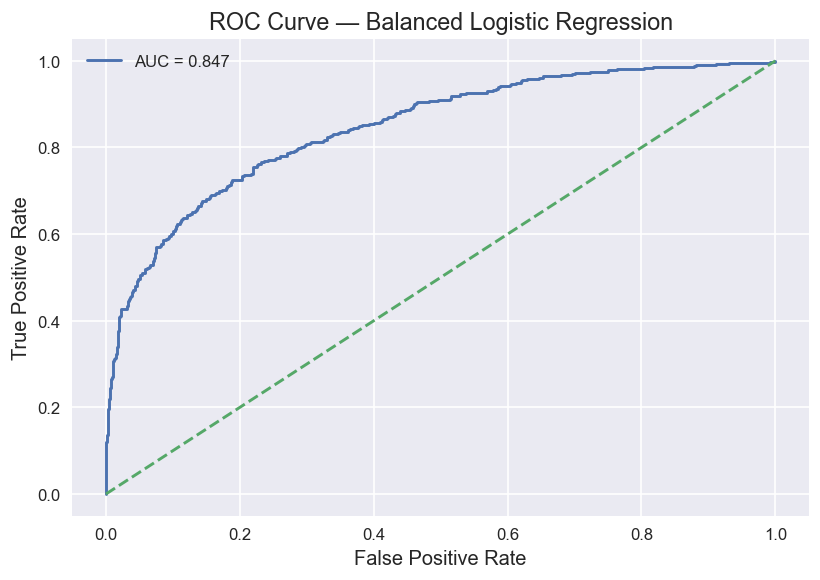

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Balanced Logistic Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

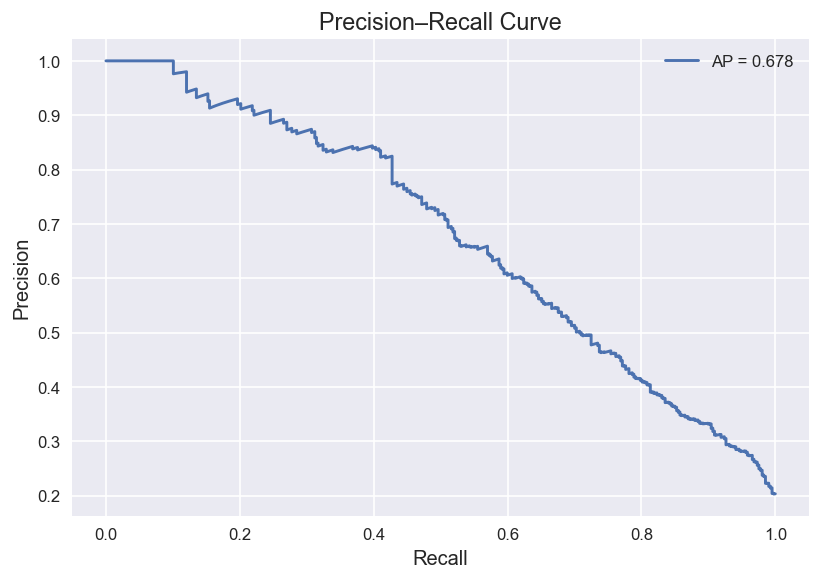

In [20]:
precisions_pr, recalls_pr, thresholds_pr = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(recalls_pr, precisions_pr, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

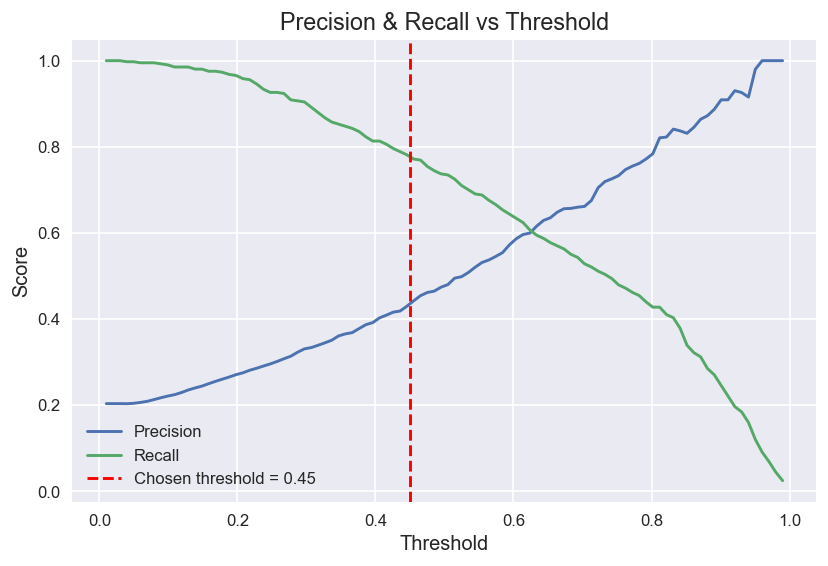

In [21]:
thresholds = np.linspace(0.01, 0.99, 100)

prec_list = []
rec_list = []

for t in thresholds:
    preds_t = (y_proba >= t).astype(int)
    prec_list.append(precision_score(y_test, preds_t, zero_division=0))
    rec_list.append(recall_score(y_test, preds_t))

plt.figure(figsize=(8,5))
plt.plot(thresholds, prec_list, label="Precision")
plt.plot(thresholds, rec_list, label="Recall")
plt.axvline(0.45, color="red", linestyle="--", label="Chosen threshold = 0.45")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
odds = pd.DataFrame({
    'feature': X_train.columns,
    'odds_ratio': np.exp(model.coef_[0])
}).sort_values('odds_ratio', ascending=False)

odds.head(20)

,feature,odds_ratio
3,age_capped,1.951815
14,age_group_46-60,1.478061
11,country_Germany,1.446181
20,products_bucket_3+,1.253801
6,many_products,1.253801
5,balance_to_salary,1.050003
2,estimated_salary,1.042615
13,age_group_31-45,1.040596
9,products_x_active,1.039354
4,is_new_customer,1.034224


- The model shows that churn risk increases mainly with age and product usage.
- Customers aged 46–60 and those with higher age overall (age_capped) have noticeably higher churn odds.
- German customers also show slightly elevated risk.
- Customers with 3+ products or generally high product activity appear more likely to churn, although these effects are moderate.
- On the other hand, being an active member, having a higher credit score, or belonging to the 60+ age group reduces churn risk.
- The strongest protective effect comes from the active × age interaction, suggesting that older active customers are the least likely to leave.

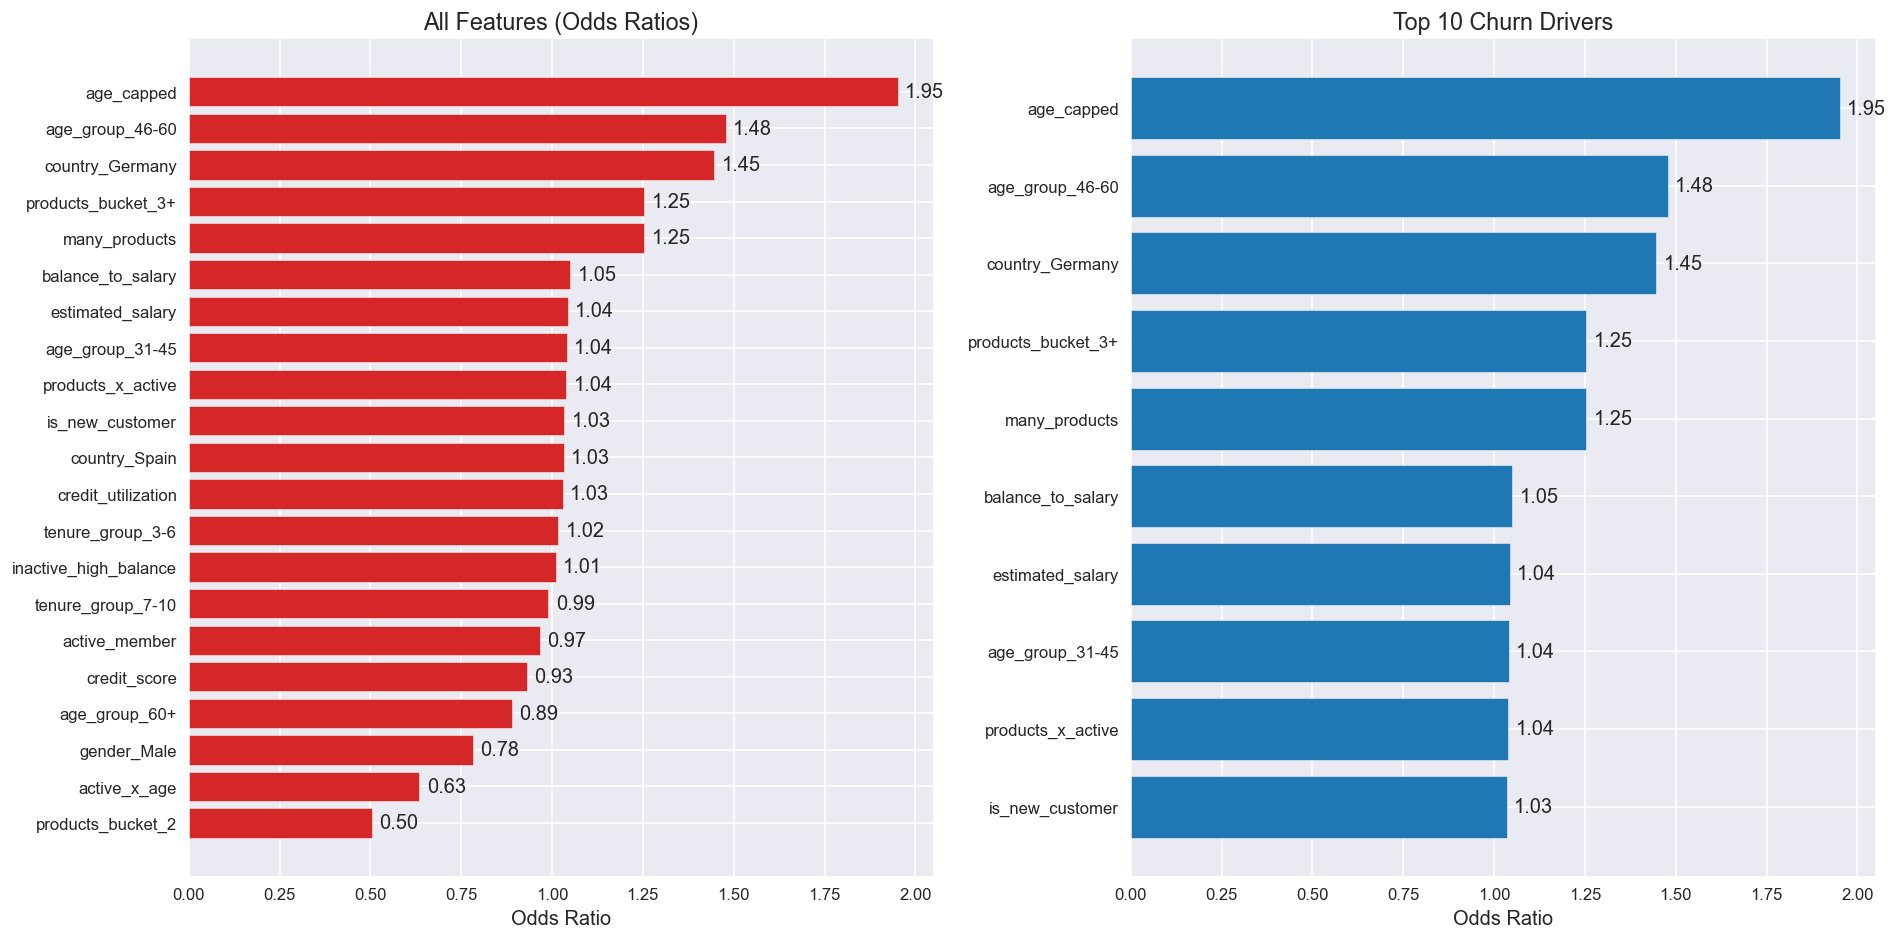

In [23]:
odds_sorted = odds.sort_values('odds_ratio', ascending=False)
top10 = odds_sorted.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: All features
axes[0].barh(odds_sorted['feature'], odds_sorted['odds_ratio'], color=CHURN_COLOR)
axes[0].set_title("All Features (Odds Ratios)")
axes[0].set_xlabel("Odds Ratio")
axes[0].invert_yaxis()
for i, v in enumerate(odds_sorted['odds_ratio']):
    axes[0].text(v + 0.02, i, f"{v:.2f}", va='center')

# Right: Top 10
axes[1].barh(top10['feature'], top10['odds_ratio'], color=RETAIN_COLOR)
axes[1].set_title("Top 10 Churn Drivers")
axes[1].set_xlabel("Odds Ratio")
axes[1].invert_yaxis()
for i, v in enumerate(top10['odds_ratio']):
    axes[1].text(v + 0.02, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()

# Conclusion 

- Customer churn is strongly associated with low activity levels, reduced engagement, and limited product usage.

- Younger customers and certain geographic segments show noticeably higher churn risk.

- Behavioral segmentation aligns well with the model’s results, confirming the importance of activity, value, and loyalty indicators.

- The Logistic Regression model provides stable performance and clear interpretability, making it suitable for understanding churn drivers.

- hreshold tuning improves the model’s ability to detect high-risk customers, increasing the usefulness of predictions for retention planning.

- The overall analysis establishes a solid foundation for data-driven customer retention strategies and highlights areas where deeper modeling could offer further gains.